#**SimPy**

SimPy é uma biblioteca em Python para simulação de eventos discretos (DES).

*   Environment — controla o tempo e agenda eventos
*   Process — funções que usam yield para serem "pausadas"
*   Event — timeout, requisição de recurso, liberação
*   Resource — servidores, máquinas, berços, caixas etc.

# **Fila M/M/1 com Registro da Ocupação Média**

In [ ]:
!pip install simpy

import simpy
import random
import statistics
import math

# ----------------------
# PARÂMETROS DO MODELO
# ----------------------
LAMBDA = 1/5   # taxa de chegada (λ) -> 0.2 clientes / hora
MU = 1/3       # taxa de serviço (μ) -> 0.333 clientes / hora
TEMPO_SIM = 50000  # tempo de simulação

tempos_espera = []
tempos_sistema = []
ocupacao = []
total_clientes = 0

def atendimento(env, nome, servidor):
    global total_clientes
    chegada = env.now
    total_clientes += 1

    with servidor.request() as req:
        yield req

        espera = env.now - chegada
        tempos_espera.append(espera)

        # Tempo de serviço ~ Exp(MU)
        tempo_servico = random.expovariate(MU)
        yield env.timeout(tempo_servico)

        saida = env.now
        tempos_sistema.append(saida - chegada)

def chegadas(env, servidor):
    i = 0
    while True:
        # Intervalo entre chegadas ~ Exp(LAMBDA)
        intervalo = random.expovariate(LAMBDA)
        yield env.timeout(intervalo)
        i += 1
        env.process(atendimento(env, f"Cliente {i}", servidor))

def monitor(env, servidor):
    while True:
        ocupacao.append(servidor.count)
        yield env.timeout(1)

# Ambiente
env = simpy.Environment()
servidor = simpy.Resource(env, capacity=1)
env.process(chegadas(env, servidor))
env.process(monitor(env, servidor))
env.run(until=TEMPO_SIM)

# ----------------------
# TEORIA M/M/1
# ----------------------
def teorico_mm1(lmbd, mu):
    rho = lmbd / mu
    if rho >= 1:
        raise ValueError("Sistema instável: λ >= μ")

    L = rho / (1 - rho)
    Lq = rho**2 / (1 - rho)
    W = 1 / (mu - lmbd)
    Wq = lmbd / (mu * (mu - lmbd))
    P0 = 1 - rho

    return {
        "rho": rho,
        "L": L,
        "Lq": Lq,
        "W": W,
        "Wq": Wq,
        "P0": P0
    }

teo = teorico_mm1(LAMBDA, MU)

print("\n===== RESULTADOS DA SIMULAÇÃO M/M/1 =====")
print(f"Clientes atendidos: {total_clientes}")
print(f"Tempo médio de espera Wq (sim): {statistics.mean(tempos_espera):.4f}")
print(f"Tempo médio no sistema W  (sim): {statistics.mean(tempos_sistema):.4f}")
print(f"Ocupação média ρ (sim):          {statistics.mean(ocupacao):.4f}")

print("\n===== RESULTADOS TEÓRICOS M/M/1 =====")
print(f"ρ   = {teo['rho']:.4f}")
print(f"Lq  = {teo['Lq']:.4f}")
print(f"L   = {teo['L']:.4f}")
print(f"Wq  = {teo['Wq']:.4f}")
print(f"W   = {teo['W']:.4f}")

print("\n===== COMPARAÇÃO DIRETA =====")
print(f"Wq sim ≈ {statistics.mean(tempos_espera):.4f}  | Wq teo = {teo['Wq']:.4f}")
print(f"W  sim ≈ {statistics.mean(tempos_sistema):.4f}  | W  teo = {teo['W']:.4f}")
print(f"ρ  sim ≈ {statistics.mean(ocupacao):.4f}  | ρ  teo = {teo['rho']:.4f}")



===== RESULTADOS DA SIMULAÇÃO M/M/1 =====
Clientes atendidos: 10157
Tempo médio de espera Wq (sim): 4.7045
Tempo médio no sistema W  (sim): 7.7339
Ocupação média ρ (sim):          0.6155

===== RESULTADOS TEÓRICOS M/M/1 =====
ρ   = 0.6000
Lq  = 0.9000
L   = 1.5000
Wq  = 4.5000
W   = 7.5000

===== COMPARAÇÃO DIRETA =====
Wq sim ≈ 4.7045  | Wq teo = 4.5000
W  sim ≈ 7.7339  | W  teo = 7.5000
ρ  sim ≈ 0.6155  | ρ  teo = 0.6000




---
# **Fila M/M/1 com Intervalo de Confiança**


---



Replicação 1: Wq=4.8070, W=7.9572
Replicação 2: Wq=3.5809, W=6.4579
Replicação 3: Wq=4.6783, W=7.6914
Replicação 4: Wq=5.5426, W=8.6233
Replicação 5: Wq=3.8735, W=6.8360
Replicação 6: Wq=3.4387, W=6.4425
Replicação 7: Wq=3.9268, W=6.9041
Replicação 8: Wq=4.8665, W=7.8601
Replicação 9: Wq=4.3669, W=7.3138
Replicação 10: Wq=6.7365, W=9.6883

===== INTERVALOS DE CONFIANÇA (95%) =====
Wq médio = 4.5818   IC95% = [3.9622, 5.2013]
W  médio = 7.5775   IC95% = [6.9440, 8.2109]


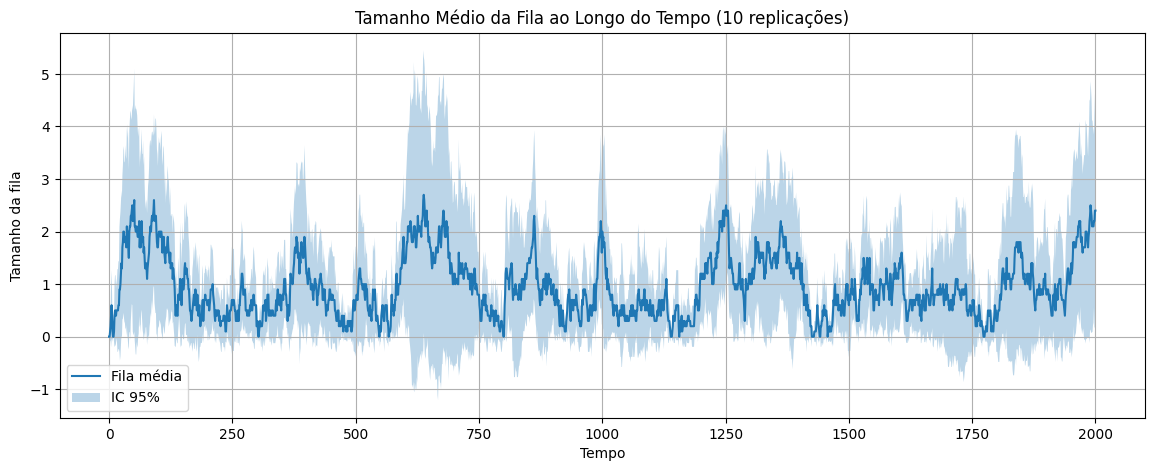

In [ ]:
import simpy
import random
import statistics
import math
import numpy as np
import matplotlib.pyplot as plt

# ----------------------
# PARÂMETROS DO MODELO
# ----------------------
LAMBDA = 1/5
MU = 1/3
TEMPO_SIM = 2000
N_REP = 10


# ======================================================
# FUNÇÃO PARA RODAR UMA REPLICAÇÃO
# ======================================================
def rodar_simulacao():

    tempos_espera = []
    tempos_sistema = []
    fila_tempo = []

    def atendimento(env, nome, servidor):
        chegada = env.now

        with servidor.request() as req:
            yield req
            tempos_espera.append(env.now - chegada)

            tempo_servico = random.expovariate(MU)
            yield env.timeout(tempo_servico)

            tempos_sistema.append(env.now - chegada)

    def chegadas(env, servidor):
        i = 0
        while True:
            yield env.timeout(random.expovariate(LAMBDA))
            i += 1
            env.process(atendimento(env, f"Cliente {i}", servidor))

    def monitor(env, servidor):
        while True:
            fila_tempo.append((env.now, len(servidor.queue)))
            yield env.timeout(1)

    env = simpy.Environment()
    servidor = simpy.Resource(env, capacity=1)
    env.process(chegadas(env, servidor))
    env.process(monitor(env, servidor))
    env.run(until=TEMPO_SIM)

    return tempos_espera, tempos_sistema, fila_tempo


# ======================================================
# RODAR AS REPLICAÇÕES
# ======================================================
resultados_Wq = []
resultados_W  = []
resultados_fila = []

for rep in range(N_REP):
    Wq_list, W_list, fila = rodar_simulacao()
    resultados_Wq.append(statistics.mean(Wq_list))
    resultados_W.append(statistics.mean(W_list))
    resultados_fila.append(fila)
    print(f"Replicação {rep+1}: Wq={statistics.mean(Wq_list):.4f}, W={statistics.mean(W_list):.4f}")


# ======================================================
# INTERVALO DE CONFIANÇA
# ======================================================
def intervalo_confianca(amostras):
    media = statistics.mean(amostras)
    desvio = statistics.stdev(amostras)
    n = len(amostras)
    erro = 1.96 * desvio / math.sqrt(n)
    return media - erro, media + erro, media

IC_Wq = intervalo_confianca(resultados_Wq)
IC_W  = intervalo_confianca(resultados_W)


# ======================================================
# IMPRIMIR RELATÓRIO
# ======================================================
print("\n===== INTERVALOS DE CONFIANÇA (95%) =====")
print(f"Wq médio = {IC_Wq[2]:.4f}   IC95% = [{IC_Wq[0]:.4f}, {IC_Wq[1]:.4f}]")
print(f"W  médio = {IC_W[2]:.4f}   IC95% = [{IC_W[0]:.4f}, {IC_W[1]:.4f}]")

# ======================================================
# PROCESSAR FILA AO LONGO DO TEMPO
# ======================================================
grid_tempo = np.arange(0, TEMPO_SIM + 1, 1)
matriz_filas = []

for fila in resultados_fila:
    tempos = [t for t, q in fila]
    valores = [q for t, q in fila]
    interp = np.interp(grid_tempo, tempos, valores)
    matriz_filas.append(interp)

matriz_filas = np.array(matriz_filas)

media_fila = np.mean(matriz_filas, axis=0)
desvio_fila = np.std(matriz_filas, axis=0, ddof=1)

IC_inf = media_fila - 1.96 * desvio_fila / np.sqrt(N_REP)
IC_sup = media_fila + 1.96 * desvio_fila / np.sqrt(N_REP)


# ======================================================
# GRÁFICO FINAL
# ======================================================
plt.figure(figsize=(14,5))
plt.plot(grid_tempo, media_fila, label="Fila média")
plt.fill_between(grid_tempo, IC_inf, IC_sup, alpha=0.3, label="IC 95%")
plt.xlabel("Tempo")
plt.ylabel("Tamanho da fila")
plt.title("Tamanho Médio da Fila ao Longo do Tempo (10 replicações)")
plt.grid(True)
plt.legend()
plt.show()


# **Fila M/M/1 com Calendário de Funcionamento (Atualização Automática)**

In [ ]:
!pip install simpy

import simpy
import random
import statistics

# ----------------------
# PARÂMETROS DO MODELO
# ----------------------
LAMBDA = 1/5       # taxa de chegada (λ)
MU = 1/3           # taxa de serviço (μ)
TEMPO_SIM = 50000  # tempo total de simulação

HORAS_DIA = 24
HORAS_PARADA = 4
HORA_INICIO_PARADA = 2  # 02h-06h

# ----------------------
# ESTATÍSTICAS
# ----------------------
tempos_espera = []
tempos_sistema = []
ocupacao = []
total_clientes = 0

# ----------------------
# EVENTO DE MÁQUINA LIGADA
# ----------------------
maquina_ligada = None

# ----------------------
# PROCESSO DO CLIENTE
# ----------------------
def atendimento(env, nome, servidor):
    global total_clientes, maquina_ligada

    chegada = env.now
    total_clientes += 1

    with servidor.request() as req:
        # Espera o recurso estar disponível
        yield req

        # Espera máquina estar ligada
        yield maquina_ligada

        espera = env.now - chegada
        tempos_espera.append(espera)

        # Serviço exponencial
        tempo_servico = random.expovariate(MU)
        yield env.timeout(tempo_servico)

        tempos_sistema.append(env.now - chegada)


# ----------------------
# GERADOR DE CHEGADAS (POISSON)
# ----------------------
def chegadas(env, servidor):
    i = 0
    while True:
        yield env.timeout(random.expovariate(LAMBDA))
        i += 1
        env.process(atendimento(env, f"Cliente {i}", servidor))

# ----------------------
# MONITORAMENTO (OCUPAÇÃO)
# ----------------------
def monitor(env, servidor):
    while True:
        ocupacao.append(servidor.count)
        yield env.timeout(1)

# ----------------------
# CALENDÁRIO DA MÁQUINA (USANDO EVENTOS)
# ----------------------
def calendario_maquina(env):
    global maquina_ligada

    while True:
        hora_atual = env.now % HORAS_DIA

        # Se estamos FORA do período de parada
        if hora_atual < HORA_INICIO_PARADA or hora_atual >= HORA_INICIO_PARADA + HORAS_PARADA:

            # Cria evento e liga máquina imediatamente
            maquina_ligada = env.event()
            maquina_ligada.succeed()

            # Tempo até início da próxima parada
            if hora_atual < HORA_INICIO_PARADA:
                tempo_ate_parada = HORA_INICIO_PARADA - hora_atual
            else:
                tempo_ate_parada = HORAS_DIA - hora_atual + HORA_INICIO_PARADA

            yield env.timeout(tempo_ate_parada)

        else:
            # Estamos dentro da janela de parada — máquina DESLIGADA
            maquina_ligada = env.event()  # ainda não 'succeed'

            # Tempo restante até ligar
            tempo_restante = (HORA_INICIO_PARADA + HORAS_PARADA) - hora_atual

            yield env.timeout(tempo_restante)

            # Ao terminar a parada, máquina RELIGA
            maquina_ligada.succeed()


# ----------------------
# EXECUÇÃO DA SIMULAÇÃO
# ----------------------
env = simpy.Environment()
servidor = simpy.Resource(env, capacity=1)

# Inicia processos
env.process(chegadas(env, servidor))
env.process(monitor(env, servidor))
env.process(calendario_maquina(env))

env.run(until=TEMPO_SIM)

# ----------------------
# RESULTADOS
# ----------------------
print("\n===== RESULTADOS DA SIMULAÇÃO (M/M/1 COM PARADAS DIÁRIAS) =====")
print(f"Clientes atendidos: {total_clientes}")
print(f"Tempo médio de espera Wq: {statistics.mean(tempos_espera):.4f}")
print(f"Tempo médio no sistema W: {statistics.mean(tempos_sistema):.4f}")
print(f"Ocupação média ρ (simulada): {statistics.mean(ocupacao):.4f}")



===== RESULTADOS DA SIMULAÇÃO (M/M/1 COM PARADAS DIÁRIAS) =====
Clientes atendidos: 9879
Tempo médio de espera Wq: 6.0185
Tempo médio no sistema W: 8.9961
Ocupação média ρ (simulada): 0.6450


# **Atendimento de Navios Porta Contêineres (Cabotagem)**

In [ ]:
!pip install simpy

import simpy
import random
import statistics

# ==========================
# PARÂMETROS
# ==========================

# Chegadas (exponencial com média de 12h)
LAMBDA = 1/12    # taxa = 1/12 → média 12 horas

# Travessia do canal (Normal 1h, desvio 0.1h)
CANAL_MEAN = 1.0     # horas (60 min)
CANAL_SD = 0.1       # horas (6 min)

# Serviço no berço: depende dos TEUs e da triangular em minutos
TEUS_TIPO1 = 3500
TEUS_TIPO2 = 5000
PERC_MOVIMENTADO = 0.20  # 20%

# Distribuição de tipos
P_TIPO1 = 0.8  # 80%
P_TIPO2 = 0.2  # 20%

# Berços (dois berços separados)
CAP_BERCO1 = 1
CAP_BERCO2 = 1

# Canal exclusivo
CAPACIDADE_CANAL = 1

# Tempo de simulação (horas)
TEMPO_SIM = 24 * 365  # 1 ano

# ==========================
# ESTATÍSTICAS
# ==========================

# Tempos médios por tipo
fila_berco_tipo1 = []
fila_berco_tipo2 = []

tempo_sistema_tipo1 = []
tempo_sistema_tipo2 = []

# (Opcional) Para ver também canal, se quiser
fila_canal_entrada_tipo1 = []
fila_canal_entrada_tipo2 = []

fila_canal_saida_tipo1 = []
fila_canal_saida_tipo2 = []

total_navios = 0
total_tipo1 = 0
total_tipo2 = 0


# ==========================
# FUNÇÕES AUXILIARES
# ==========================
def tempo_servico_berco(teus):
    """
    Calcula tempo de serviço no berço com base em:
    - 20% dos TEUs movimentados
    - tempo por movimentação ~ triangular(1.0, 1.5, 1.8) minutos

    Retorna tempo em HORAS.
    """
    movimentos = PERC_MOVIMENTADO * teus
    tempo_por_movimento_min = random.triangular(0.666, 1.2, 0.90)  # min
    tempo_total_min = movimentos * tempo_por_movimento_min
    return tempo_total_min / 60.0  # converte para horas


# ==========================
# PROCESSO DO NAVIO
# ==========================
def atendimento(env, nome, berco1, berco2, canal):
    global total_navios, total_tipo1, total_tipo2

    chegada = env.now
    total_navios += 1

    # Sorteia tipo de navio (1 ou 2)
    if random.random() < P_TIPO1:
        tipo = 1
        total_tipo1 += 1
        teus = TEUS_TIPO1
    else:
        tipo = 2
        total_tipo2 += 1
        teus = TEUS_TIPO2

    # ==========================
    # 1️ - ESCOLHA / RESTRIÇÃO DO BERÇO
    # ==========================
    # Tipo 1 pode ir para berço 1 ou 2 → escolhe o que tiver fila menor
    if tipo == 1:
        fila_1 = berco1.count + len(berco1.queue)
        fila_2 = berco2.count + len(berco2.queue)
        if fila_1 <= fila_2:
            berco_alvo = berco1
        else:
            berco_alvo = berco2
    else:
        # Tipo 2 só pode usar o berço 2 (restrição de calado)
        berco_alvo = berco2

    # ==========================
    # 2️ - FILA DO BERÇO
    # ==========================
    inicio_fila_berco = env.now
    with berco_alvo.request() as req_berco:
        yield req_berco
        tempo_espera_berco = env.now - inicio_fila_berco

        if tipo == 1:
            fila_berco_tipo1.append(tempo_espera_berco)
        else:
            fila_berco_tipo2.append(tempo_espera_berco)

        # ==========================
        # 3️ - DEPOIS DO BERÇO, PEDIR CANAL DE ENTRADA
        # ==========================
        inicio_fila_canal_ent = env.now
        with canal.request() as req_canal_ent:
            yield req_canal_ent
            tempo_fila_canal_ent = env.now - inicio_fila_canal_ent

            if tipo == 1:
                fila_canal_entrada_tipo1.append(tempo_fila_canal_ent)
            else:
                fila_canal_entrada_tipo2.append(tempo_fila_canal_ent)

            # Travessia de ENTRADA
            tempo_ent = max(0, random.normalvariate(CANAL_MEAN, CANAL_SD))
            yield env.timeout(tempo_ent)

        # ==========================
        # 4️ - SERVIÇO NO BERÇO (MOVIMENTAÇÃO DE CONTÊINERES)
        # ==========================
        tempo_servico = tempo_servico_berco(teus)
        yield env.timeout(tempo_servico)

        # ==========================
        # 5️ - CANAL DE SAÍDA
        # ==========================
        inicio_fila_canal_sai = env.now
        with canal.request() as req_canal_sai:
            yield req_canal_sai
            tempo_fila_canal_sai = env.now - inicio_fila_canal_sai

            if tipo == 1:
                fila_canal_saida_tipo1.append(tempo_fila_canal_sai)
            else:
                fila_canal_saida_tipo2.append(tempo_fila_canal_sai)

            tempo_sai = max(0, random.normalvariate(CANAL_MEAN, CANAL_SD))
            yield env.timeout(tempo_sai)

    # ==========================
    # 6️ - TEMPO TOTAL NO TERMINAL
    # ==========================
    tempo_total = env.now - chegada
    if tipo == 1:
        tempo_sistema_tipo1.append(tempo_total)
    else:
        tempo_sistema_tipo2.append(tempo_total)

# ==========================
# GERADOR DE CHEGADAS
# ==========================
def chegadas(env, berco1, berco2, canal):
    i = 0
    while True:
        # Processo Poisson (exponencial entre chegadas)
        yield env.timeout(random.expovariate(LAMBDA))
        i += 1
        env.process(atendimento(env, f"Navio {i}", berco1, berco2, canal))

# ==========================
# EXECUÇÃO
# ==========================
env = simpy.Environment()
berco1 = simpy.Resource(env, capacity=CAP_BERCO1)
berco2 = simpy.Resource(env, capacity=CAP_BERCO2)
canal = simpy.Resource(env, capacity=CAPACIDADE_CANAL)
env.process(chegadas(env, berco1, berco2, canal))
env.run(until=TEMPO_SIM)

# ==========================
# RESULTADOS
# ==========================
print("\n===== RESULTADOS — DOIS TIPOS DE NAVIO =====")
print(f"Navios processados: {total_navios}")
print(f"  Tipo 1: {total_tipo1}")
print(f"  Tipo 2: {total_tipo2}")

def media(v):
    return statistics.mean(v) if v else 0.0

print("\n--- TEMPO MÉDIO EM FILA DE BERÇO ---")
print(f"Tipo 1: {media(fila_berco_tipo1):.2f} h")
print(f"Tipo 2: {media(fila_berco_tipo2):.2f} h")

print("\n--- TEMPO MÉDIO NO TERMINAL ---")
print(f"Tipo 1: {media(tempo_sistema_tipo1):.2f} h")
print(f"Tipo 2: {media(tempo_sistema_tipo2):.2f} h")



===== RESULTADOS — DOIS TIPOS DE NAVIO =====
Navios processados: 693
  Tipo 1: 573
  Tipo 2: 120

--- TEMPO MÉDIO EM FILA DE BERÇO ---
Tipo 1: 3.36 h
Tipo 2: 3.93 h

--- TEMPO MÉDIO NO TERMINAL ---
Tipo 1: 16.27 h
Tipo 2: 21.40 h


# **Fila com Prioridade**

=== PRIORITYRESOURCE (COM ALEATORIEDADE) ===
Média das esperas: 98.04 h
IC95% da média: [96.46, 99.63] h
Percentis individuais (2.5, 50, 97.5): 0.69, 121.61, 197.19 h


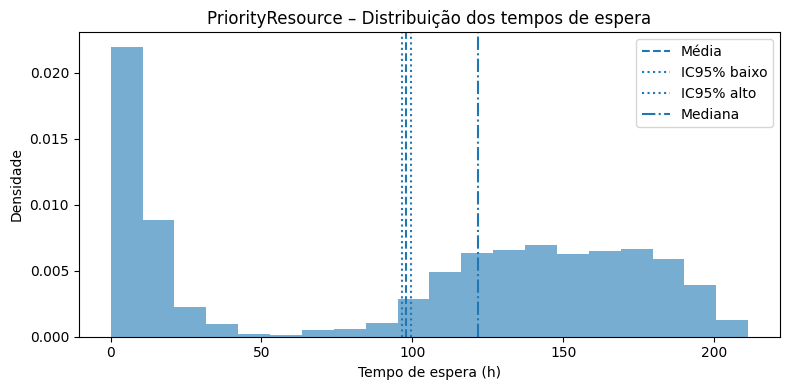

In [1]:
!pip install simpy
import simpy
import random
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# PARÂMETROS
# -----------------------------
N_REP = 50         # número de replicações
N_NAVIOS = 100
P_PRIORITARIO = 0.3

# Chegadas e serviço com aleatoriedade
LAMBDA_CHEGADA = 1.0     # taxa de chegadas (1/h → exponencial)
MEAN_ATRACACAO = 3.0
SD_ATRACACAO = 0.5

# -----------------------------
# PROCESSOS
# -----------------------------
def tempo_servico():
    # Normal truncada para evitar tempos negativos
    t = random.normalvariate(MEAN_ATRACACAO, SD_ATRACACAO)
    return max(0.1, t)

def intervalo_entre_chegadas():
    return random.expovariate(LAMBDA_CHEGADA)

def processo_navio(env, name, prioridade, berço, esperas):
    chegada = env.now
    with berço.request(priority=prioridade) as req:
        yield req
        esperas.append(env.now - chegada)
        yield env.timeout(tempo_servico())

def gerador_navios(env, berço, esperas):
    for i in range(N_NAVIOS):
        prioridade = 0 if random.random() < P_PRIORITARIO else 1
        env.process(processo_navio(env, f"N{i}", prioridade, berço, esperas))
        yield env.timeout(intervalo_entre_chegadas())

def simular(seed):
    random.seed(seed)
    env = simpy.Environment()
    berço = simpy.PriorityResource(env, capacity=1)
    esperas = []
    env.process(gerador_navios(env, berço, esperas))
    env.run()
    return esperas

# -----------------------------
# MONTE CARLO
# -----------------------------
todas_esperas = []
medias_rep = []

for rep in range(N_REP):
    tempos = simular(rep)
    medias_rep.append(np.mean(tempos))
    todas_esperas.extend(tempos)

# -----------------------------
# ESTATÍSTICAS
# -----------------------------
todas_esperas = np.array(todas_esperas)
medias_rep = np.array(medias_rep)

p2_5, p50, p97_5 = np.percentile(todas_esperas, [2.5, 50, 97.5])
mean_wait = medias_rep.mean()
sem = medias_rep.std(ddof=1) / np.sqrt(len(medias_rep))
ci_low = mean_wait - 1.96 * sem
ci_high = mean_wait + 1.96 * sem

print("=== PRIORITYRESOURCE (COM ALEATORIEDADE) ===")
print(f"Média das esperas: {mean_wait:.2f} h")
print(f"IC95% da média: [{ci_low:.2f}, {ci_high:.2f}] h")
print(f"Percentis individuais (2.5, 50, 97.5): {p2_5:.2f}, {p50:.2f}, {p97_5:.2f} h")

# -----------------------------
# GRÁFICO
# -----------------------------
plt.figure(figsize=(8,4))
plt.hist(todas_esperas, bins=20, density=True, alpha=0.6)
plt.axvline(mean_wait, linestyle="--", label="Média")
plt.axvline(ci_low, linestyle=":", label="IC95% baixo")
plt.axvline(ci_high, linestyle=":", label="IC95% alto")
plt.axvline(p50, linestyle="-.", label="Mediana")
plt.title("PriorityResource – Distribuição dos tempos de espera")
plt.xlabel("Tempo de espera (h)")
plt.ylabel("Densidade")
plt.legend()
plt.tight_layout()
plt.show()


=== PRIORITYRESOURCE – CUSTOS ===
Média do custo (por navio): 490,223.47
IC 95% da média: [482,301.37, 498,145.57]
Percentis individuais: 2.5% = 3,430.35, mediana = 608,058.80, 97.5% = 985,963.51


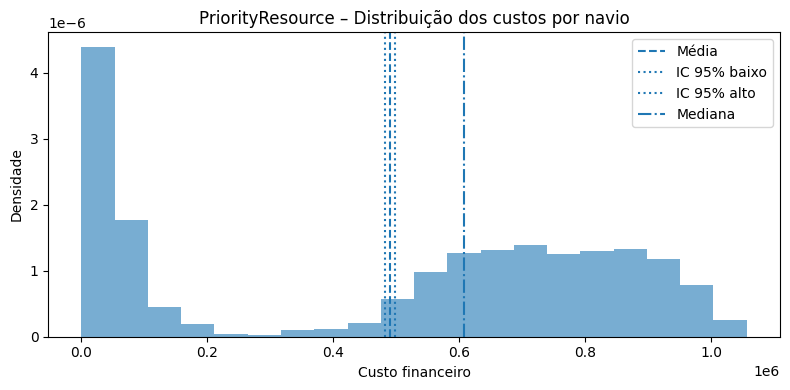

In [2]:
import simpy
import random
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# PARÂMETROS
# =============================================
N_REP = 50         # número de replicações
N_NAVIOS = 100
P_PRIORITARIO = 0.3

# Chegadas e serviço com aleatoriedade
LAMBDA_CHEGADA = 1.0     # taxa de chegadas (1/h → exponencial)
MEAN_ATRACACAO = 3.0
SD_ATRACACAO = 0.5

CUSTO_ESPERA = 5000  # custo financeiro por hora de espera


# =============================================
# FUNÇÕES ALEATÓRIAS
# =============================================
def tempo_servico():
    # Normal truncada para evitar tempos negativos
    t = random.normalvariate(MEAN_ATRACACAO, SD_ATRACACAO)
    return max(0.1, t)

def intervalo_entre_chegadas():
    return random.expovariate(LAMBDA_CHEGADA)

# =============================================
# PROCESSOS
# =============================================
def processo_navio(env, name, prioridade, berço, custos):
    chegada = env.now
    with berço.request(priority=prioridade) as req:
        yield req
        espera = env.now - chegada
        custo = espera * CUSTO_ESPERA
        custos.append(custo)
        yield env.timeout(tempo_servico())

def gerador_navios(env, berço, custos):
    for i in range(N_NAVIOS):
        prioridade = 0 if random.random() < P_PRIORITARIO else 1
        env.process(processo_navio(env, f"N{i}", prioridade, berço, custos))
        yield env.timeout(intervalo_entre_chegadas())

def simular(seed):
    random.seed(seed)
    env = simpy.Environment()
    berço = simpy.PriorityResource(env, capacity=1)
    custos = []
    env.process(gerador_navios(env, berço, custos))
    env.run()
    return custos

# =============================================
# MONTE CARLO
# =============================================
todos_custos = []
medias_rep = []

for rep in range(N_REP):
    custos = simular(rep)
    medias_rep.append(np.mean(custos))
    todos_custos.extend(custos)

todos_custos = np.array(todos_custos)
medias_rep = np.array(medias_rep)


# =============================================
# ESTATÍSTICAS
# =============================================
p2_5, p50, p97_5 = np.percentile(todos_custos, [2.5, 50, 97.5])
mean_cost = medias_rep.mean()

sem = medias_rep.std(ddof=1) / np.sqrt(len(medias_rep))
ci_low = mean_cost - 1.96 * sem
ci_high = mean_cost + 1.96 * sem

print("=== PRIORITYRESOURCE – CUSTOS ===")
print(f"Média do custo (por navio): {mean_cost:,.2f}")
print(f"IC 95% da média: [{ci_low:,.2f}, {ci_high:,.2f}]")
print(f"Percentis individuais: 2.5% = {p2_5:,.2f}, mediana = {p50:,.2f}, 97.5% = {p97_5:,.2f}")

# Gráfico
plt.figure(figsize=(8,4))
plt.hist(todos_custos, bins=20, density=True, alpha=0.6)
plt.axvline(mean_cost, linestyle="--", label="Média")
plt.axvline(ci_low, linestyle=":", label="IC 95% baixo")
plt.axvline(ci_high, linestyle=":", label="IC 95% alto")
plt.axvline(p50, linestyle="-.", label="Mediana")
plt.title("PriorityResource – Distribuição dos custos por navio")
plt.xlabel("Custo financeiro")
plt.ylabel("Densidade")
plt.legend()
plt.tight_layout()
plt.show()

# **Interrupção do Recurso**
**Preemptive scheduling** → o sistema interrompe um processo para dar lugar a outro.
**Non-preemptive scheduling** → o processo roda até terminar.


=== PREEMPTIVERESOURCE (COM ALEATORIEDADE) ===
Tempo médio no sistema: 473.51 h
IC95% da média: [469.86, 477.16] h
Percentis (2.5, 50, 97.5): 4.02, 507.94, 918.17 h


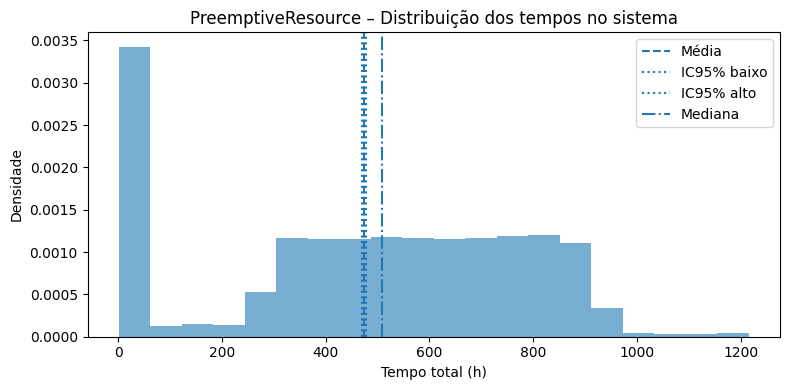

In [3]:
import simpy
import random
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# PARÂMETROS
# -----------------------------
N_REP = 50
N_NAVIOS = 300
P_EMERGENCIA = 0.2

LAMBDA_CHEGADA = 1.0
MEAN_ATRACACAO = 4.0
SD_ATRACACAO = 0.7

# -----------------------------
# FUNÇÕES ALEATÓRIAS
# -----------------------------
def tempo_atracacao():
    t = random.normalvariate(MEAN_ATRACACAO, SD_ATRACACAO)
    return max(0.2, t)

def intervalo_entre_chegadas():
    return random.expovariate(LAMBDA_CHEGADA)

# -----------------------------
# PROCESSOS
# -----------------------------
def processo_navio_preemptivo(env, name, prioridade, berço, tempos_totais):
    chegada = env.now

    while True:
        with berço.request(priority=prioridade, preempt=True) as req:
            try:
                yield req
                yield env.timeout(tempo_atracacao())
                tempos_totais.append(env.now - chegada)
                break
            except simpy.Interrupt:
                continue

def gerador_navios_preemptivo(env, berço, tempos_totais):
    for i in range(N_NAVIOS):
        prioridade = 0 if random.random() < P_EMERGENCIA else 1
        env.process(processo_navio_preemptivo(env, f"N{i}", prioridade, berço, tempos_totais))
        yield env.timeout(intervalo_entre_chegadas())

def simular_preemptivo(seed):
    random.seed(seed)
    env = simpy.Environment()
    berço = simpy.PreemptiveResource(env, capacity=1)
    tempos = []
    env.process(gerador_navios_preemptivo(env, berço, tempos))
    env.run()
    return tempos

# -----------------------------
# MONTE CARLO
# -----------------------------
todos_tempos = []
medias_rep = []

for rep in range(N_REP):
    tempos = simular_preemptivo(1000 + rep)
    todos_tempos.extend(tempos)
    medias_rep.append(np.mean(tempos))

# -----------------------------
# ESTATÍSTICAS
# -----------------------------
todos_tempos = np.array(todos_tempos)
medias_rep = np.array(medias_rep)

p2_5, p50, p97_5 = np.percentile(todos_tempos, [2.5, 50, 97.5])
mean_total = medias_rep.mean()
sem = medias_rep.std(ddof=1) / np.sqrt(len(medias_rep))
ci_low = mean_total - 1.96 * sem
ci_high = mean_total + 1.96 * sem

print("\n=== PREEMPTIVERESOURCE (COM ALEATORIEDADE) ===")
print(f"Tempo médio no sistema: {mean_total:.2f} h")
print(f"IC95% da média: [{ci_low:.2f}, {ci_high:.2f}] h")
print(f"Percentis (2.5, 50, 97.5): {p2_5:.2f}, {p50:.2f}, {p97_5:.2f} h")

# -----------------------------
# GRÁFICO
# -----------------------------
plt.figure(figsize=(8,4))
plt.hist(todos_tempos, bins=20, density=True, alpha=0.6)
plt.axvline(mean_total, linestyle="--", label="Média")
plt.axvline(ci_low, linestyle=":", label="IC95% baixo")
plt.axvline(ci_high, linestyle=":", label="IC95% alto")
plt.axvline(p50, linestyle="-.", label="Mediana")
plt.title("PreemptiveResource – Distribuição dos tempos no sistema")
plt.xlabel("Tempo total (h)")
plt.ylabel("Densidade")
plt.legend()
plt.tight_layout()
plt.show()


# **Carregamento de um navio com soja**

In [4]:
!pip install simpy

import simpy
import random

# =======================================================
# PARÂMETROS DO MODELO
# =======================================================
CAPACIDADE_SILO = 43000      # toneladas de soja disponíveis
TAXA_CARREGAMENTO = 2000     # t/h do carregador (shiploader)
CARGA_NAVIO = 50000          # t que o navio precisa carregar
TEMPO_ATRACACAO = 2          # h para atracar e preparar o carregamento

# =======================================================
# PROCESSO: SILO
# =======================================================
class Silo:
    def __init__(self, env, capacidade_inicial):
        self.env = env
        self.capacidade = capacidade_inicial

    def retirar(self, quantidade):
        """Retira soja do silo, respeitando limite."""
        retirada_real = min(quantidade, self.capacidade)
        self.capacidade -= retirada_real
        return retirada_real

# =======================================================
# PROCESSO: CARREGAMENTO DO NAVIO
# =======================================================
def carregar_navio(env, nome, berco, silo):
    chegada = env.now
    print(f"{env.now:.2f} h - {nome} chegou ao porto.")

    # 1. Atracar no berço
    with berco.request() as req:
        yield req

        print(f"{env.now:.2f} h - {nome} iniciou atracação.")
        yield env.timeout(TEMPO_ATRACACAO)

        print(f"{env.now:.2f} h - {nome} começou o carregamento.")
        carga_restante = CARGA_NAVIO

        # 2. Processo de carregamento contínuo
        while carga_restante > 0 and silo.capacidade > 0:
            # Shiploader tenta carregar em 1 hora
            yield env.timeout(1)

            quantidade = silo.retirar(TAXA_CARREGAMENTO)
            carga_restante -= quantidade

            print(f"{env.now:.2f} h - {nome} carregou {quantidade:.0f} t "
                  f"(restam {max(carga_restante, 0):.0f} t para completar).")

        if carga_restante > 0:
            print(f"{env.now:.2f} h - {nome} saiu INCOMPLETO! Faltaram {carga_restante:.0f} t.")
        else:
            print(f"{env.now:.2f} h - {nome} carregou COMPLETO e desatracou.")

    tempo_total = env.now - chegada
    print(f"==> Tempo total do {nome}: {tempo_total:.2f} h\n")

# =======================================================
# SIMULAÇÃO
# =======================================================
env = simpy.Environment()
berco = simpy.Resource(env, capacity=1)
silo = Silo(env, CAPACIDADE_SILO)
env.process(carregar_navio(env, "Navio Graneleiro", berco, silo))
env.run(until=200)



0.00 h - Navio Graneleiro chegou ao porto.
0.00 h - Navio Graneleiro iniciou atracação.
2.00 h - Navio Graneleiro começou o carregamento.
3.00 h - Navio Graneleiro carregou 2000 t (restam 48000 t para completar).
4.00 h - Navio Graneleiro carregou 2000 t (restam 46000 t para completar).
5.00 h - Navio Graneleiro carregou 2000 t (restam 44000 t para completar).
6.00 h - Navio Graneleiro carregou 2000 t (restam 42000 t para completar).
7.00 h - Navio Graneleiro carregou 2000 t (restam 40000 t para completar).
8.00 h - Navio Graneleiro carregou 2000 t (restam 38000 t para completar).
9.00 h - Navio Graneleiro carregou 2000 t (restam 36000 t para completar).
10.00 h - Navio Graneleiro carregou 2000 t (restam 34000 t para completar).
11.00 h - Navio Graneleiro carregou 2000 t (restam 32000 t para completar).
12.00 h - Navio Graneleiro carregou 2000 t (restam 30000 t para completar).
13.00 h - Navio Graneleiro carregou 2000 t (restam 28000 t para completar).
14.00 h - Navio Graneleiro carreg

# **Carregamento de um navio com soja (2)**

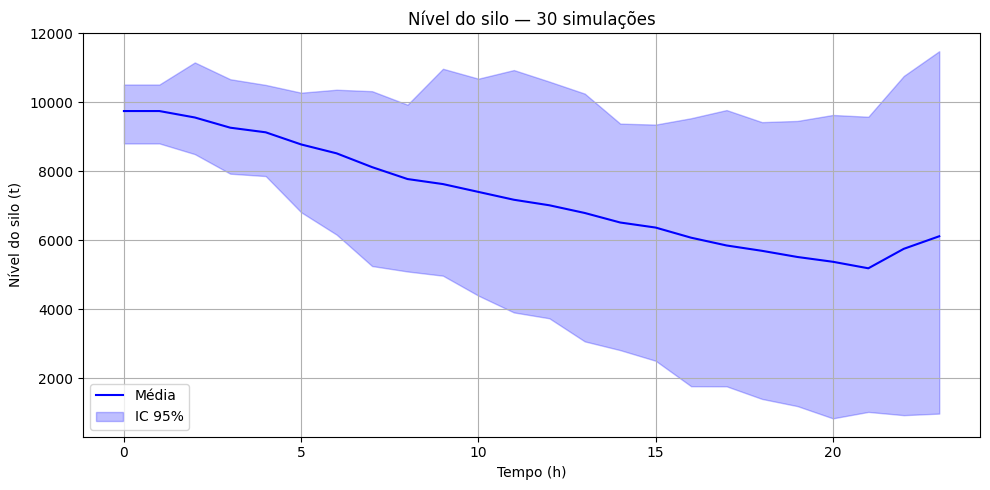

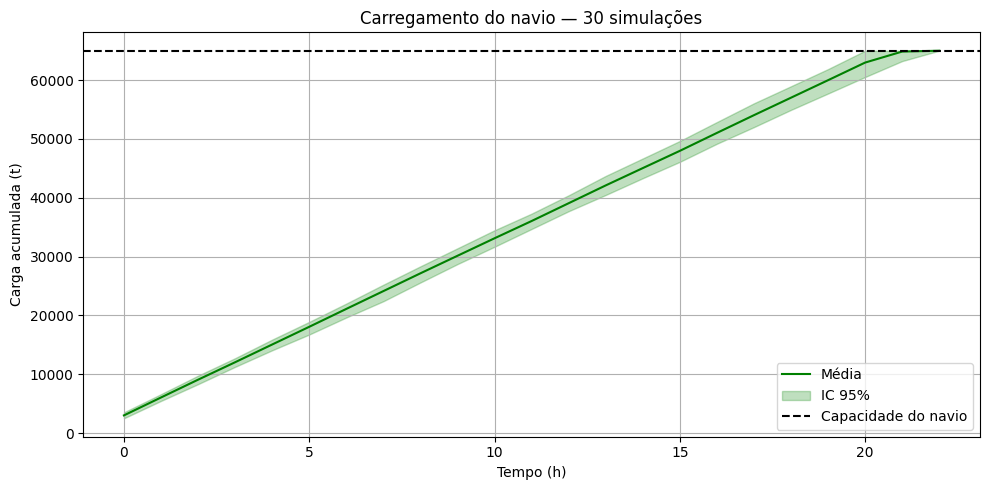

In [5]:
!pip install simpy
import simpy
import random
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# PARÂMETROS DO MODELO
# -----------------------------
CAPACIDADE_NAVIO = 65000  # toneladas
CAPACIDADE_SILO = 100000  # toneladas
SILO_CAP_INICIAL = 10000  # toneladas

TAXA_MEDIA_CARREGAMENTO_NAVIO = 3000    # toneladas / hora
TAXA_MEDIA_RECEBIMENTO_CARGA = 2750     # toneladas / hora

CV_CARREGAMENTO_NAVIO = 0.075   # coeficiente de variação
CV_RECEBIMENTO_CARGA = 0.15     # coeficiente de variação

DESVIO_PADRAO_CARREGAMENTO = TAXA_MEDIA_CARREGAMENTO_NAVIO * CV_CARREGAMENTO_NAVIO
DESVIO_PADRAO_RECEBIMENTO = TAXA_MEDIA_RECEBIMENTO_CARGA * CV_RECEBIMENTO_CARGA

N_SIM = 30  # número de simulações

# -----------------------------
# PROCESSOS DO SIMPY
# -----------------------------
def carrega_navio(env, silo, ship_progress, evento_concluido):
    """Carrega o navio até completar sua capacidade."""
    carga_carregada_navio = 0
    while carga_carregada_navio < CAPACIDADE_NAVIO:

        taxa = max(0, random.normalvariate(TAXA_MEDIA_CARREGAMENTO_NAVIO, DESVIO_PADRAO_CARREGAMENTO))
        quantidade = min(taxa, CAPACIDADE_NAVIO - carga_carregada_navio)
        yield silo.get(quantidade)

        carga_carregada_navio += quantidade
        ship_progress.append(carga_carregada_navio)
        yield env.timeout(1)  # avança 1 hora

    evento_concluido.succeed()

def reposição_silo(env, silo):
    """Reabastece o silo continuamente."""
    while True:
        taxa = max(0, random.normalvariate(TAXA_MEDIA_RECEBIMENTO_CARGA, DESVIO_PADRAO_RECEBIMENTO))
        yield silo.put(taxa)
        yield env.timeout(1)

def monitor_silo(env, silo, levels):
    """Registra o nível do silo a cada hora."""
    while True:
        levels.append(silo.level)
        yield env.timeout(1)

# -----------------------------
# EXECUÇÃO DAS SIMULAÇÕES
# -----------------------------
all_silo_levels = []
all_ship_progress = []

max_len_silo = 0
max_len_ship = 0

for _ in range(N_SIM):

    env = simpy.Environment()
    silo = simpy.Container(env, init=SILO_CAP_INICIAL, capacity=CAPACIDADE_SILO)

    silo_levels = []
    ship_progress = []

    evento_concluido = env.event()

    env.process(carrega_navio(env, silo, ship_progress, evento_concluido))
    env.process(reposição_silo(env, silo))
    env.process(monitor_silo(env, silo, silo_levels))

    env.run(until=evento_concluido)

    all_silo_levels.append(silo_levels)
    all_ship_progress.append(ship_progress)

    max_len_silo = max(max_len_silo, len(silo_levels))
    max_len_ship = max(max_len_ship, len(ship_progress))


# -----------------------------
# COMPLETA A SÉRIE (IGUALA)
# -----------------------------
def completa_serie(serie, tamanho):
    """Completa séries com o último valor para igualar os comprimentos."""
    serie_completada = []
    for s in serie:
        if len(s) < tamanho:
            valor_rep = s[-1]
            serie_completada.append(s + [valor_rep] * (tamanho - len(s)))
        else:
            serie_completada.append(s)
    return np.array(serie_completada)


# Ajuste das matrizes
silo_mat = completa_serie(all_silo_levels, max_len_silo)
ship_mat = completa_serie(all_ship_progress, max_len_ship)

# -----------------------------
# ESTATÍSTICAS (MÉDIA + IC 95%)
# -----------------------------
def stats(mat):
    mean = mat.mean(axis=0)
    low = np.percentile(mat, 2.5, axis=0)
    high = np.percentile(mat, 97.5, axis=0)
    return mean, low, high

silo_mean, silo_low, silo_high = stats(silo_mat)
ship_mean, ship_low, ship_high = stats(ship_mat)


# -----------------------------
# GRÁFICO 1 — NÍVEL DO SILO COM IC95%
# -----------------------------
t_silo = np.arange(max_len_silo)

plt.figure(figsize=(10,5))
plt.plot(t_silo, silo_mean, label="Média", color="blue")
plt.fill_between(t_silo, silo_low, silo_high, color="blue", alpha=0.25, label="IC 95%")
plt.xlabel("Tempo (h)")
plt.ylabel("Nível do silo (t)")
plt.title(f"Nível do silo — {N_SIM} simulações")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# -----------------------------
# GRÁFICO 2 — CARREGAMENTO DO NAVIO COM IC95%
# -----------------------------
t_ship = np.arange(max_len_ship)

plt.figure(figsize=(10,5))
plt.plot(t_ship, ship_mean, label="Média", color="green")
plt.fill_between(t_ship, ship_low, ship_high, color="green", alpha=0.25, label="IC 95%")
plt.axhline(CAPACIDADE_NAVIO, color="black", linestyle="--", label="Capacidade do navio")
plt.xlabel("Tempo (h)")
plt.ylabel("Carga acumulada (t)")
plt.title(f"Carregamento do navio — {N_SIM} simulações")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
